# 🛰️ GEE Setup & Landsat Imagery
**ESIIL STARS 2026 · SICK**

In this notebook you will:
1. Create a Google Earth Engine account
2. Understand how GEE works and what it costs
3. Authenticate and initialize GEE in Python
4. Load and visualize Landsat satellite imagery of CSU campus
5. Compare true-color and false-color composites across two years

**⏱ Estimated time:** 45–60 minutes

⚠️ **Branch check** — before running any cells, confirm you are on **your own branch**, not `main`.
In VS Code, open the **Source Control** panel (branch icon in the left sidebar).

1. Look at the current branch name in the Source Control view or status bar."
2. If you are on `main`, click the branch name in the status bar."
3. Choose **Create new branch...** and name it `yourname`."
4. Make sure that new branch is now selected before running notebook cells."

---
## Part 0: What is GEE and How Do You Get Access?

### What is Google Earth Engine?

GEE is a cloud platform that hosts petabytes of satellite imagery and geospatial datasets — Landsat, Sentinel, MODIS, NLCD, DEMs, climate data — and lets you run analysis on Google's servers without downloading anything. Instead of:

```
Download 40 GB of Landsat tiles → process locally → crash your laptop
```

You write Python (or JavaScript) that runs on Google's infrastructure and returns only the result you need — a table, a chart, a small image.

### Is it free?

**Yes, for academic use.** GEE remains free for students, faculty, and staff at universities using it for research or teaching. You do not need a billing account.

A few things have changed recently though:
- **Cloud Projects are now required** (since November 2024). You can't use GEE without one — but creating one is free.
- **Noncommercial quota tiers are now enforced** (since April 2026). Free accounts have monthly compute limits. The default **Community Tier** is sufficient for this project since we always request small summary results, never download raw rasters. If you ever hit the limit, computations slow down — nothing gets billed.

> ⚠️ **Each person must create their own Cloud Project.** Don't share one project between teammates — you'd share a quota pool, and one person's heavy computation would slow everyone else down.

### Step-by-step account setup

**Step 1: Sign up**
1. Go to **[earthengine.google.com](https://earthengine.google.com/)** and click **Get Started**.
2. Sign in with a Google account (Gmail or university Google account both work).

**Step 2: Create a Cloud Project**
1. Click **"Register a Noncommercial or Commercial Cloud project"**.
2. Select **"Unpaid usage"** → **"Academia & Research"**.
3. Click **"Create a new Google Cloud Project"** and give it a name like `ee-yourname` (must be globally unique).
4. Accept the Terms of Service and click **Register**.

**Step 3: Note your Project ID**
After registering you'll see your **Project ID** (e.g. `ee-yourname-abc123`). Write it down — you'll paste it into every notebook.

### Common issues

| Problem | Fix |
|---------|-----|
| "Permission denied" | Wrong Google account. Sign in with the one you registered with. |
| Can't create a Cloud Project | University account may be restricted. Try a personal Gmail. |
| "Earth Engine API not enabled" | Go to [console.cloud.google.com](https://console.cloud.google.com), select your project, search "Earth Engine API", click **Enable**. |
| Computations are very slow | You may have hit the Community Tier quota. Reduce AOI size or wait for monthly reset. |
| Auth window doesn't appear | In Codespaces the auth popup appears **at the top** of the browser — look up! |

### Checking quota and running tasks

To see your quota usage:
1. Go to [console.cloud.google.com](https://console.cloud.google.com)
2. Select your project → search **"Earth Engine API"** → **Quotas & System Limits**

To check running tasks from Python:
```python
tasks = ee.batch.Task.list()
for task in tasks[:5]:
    print(task.status())
```

Or visit the **Tasks tab** at [code.earthengine.google.com](https://code.earthengine.google.com) for a visual dashboard.

---
## Part 1: Import, Authenticate & Initialize

In [1]:
import ee
import geemap
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
from IPython.display import display, HTML

def show_map(m):
    """Reliably display a geemap Map in Codespaces."""
    try:
        display(m)
    except Exception:
        display(HTML(m.to_html()))

print("✅ All imports successful!")

✅ All imports successful!


### Authenticate

Run the cell below. A URL will appear — **click it**, sign in, copy the authorization code, and paste it back here.

> The auth popup appears **at the top of the browser window** in Codespaces — scroll up if you don't see it.

In [2]:
ee.Authenticate()

True

### Initialize

Replace `'YOUR-PROJECT-ID'` with the Project ID from Step 3 of Part 0.

Not sure what yours is? Go to [console.cloud.google.com](https://console.cloud.google.com), click the project selector at the top, and copy the value in the **Project ID** column (not the project number).

In [3]:
PROJECT_ID = 'ee-xs8091'   # ⚠️ replace this

ee.Initialize(project=PROJECT_ID)
print(f"✅ Earth Engine initialized — project: {PROJECT_ID}")

✅ Earth Engine initialized — project: ee-xs8091


---
## Part 2: Define the Study Area — CSU Campus

We'll use CSU Fort Collins as a small, familiar AOI to practice on before scaling up to the full Front Range.

**Key concept:** In GEE, an `ee.Geometry` is a shape that lives on Google's servers — you're not downloading a shapefile, just telling GEE where to look.

In [4]:
csu_lon, csu_lat = -105.0844, 40.5734

# 1 km buffer → bounding box
csu_aoi = ee.Geometry.Point([csu_lon, csu_lat]).buffer(1000).bounds()

Map = geemap.Map(center=[csu_lat, csu_lon], zoom=14)
Map.addLayer(csu_aoi, {'color': 'blue'}, 'CSU Study Area')
show_map(Map)

Map(center=[40.5734, -105.0844], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

---
## Part 3: Landsat Satellite Imagery

### What is Landsat?

Landsat is a series of US satellites that have continuously photographed Earth since 1972 — the longest continuous record of Earth's surface from space. Each satellite captures the same location every 16 days.

We'll use **Landsat 8** (launched 2013), which measures light in 11 spectral bands. Unlike a regular camera, it captures wavelengths your eyes can't see — including near-infrared (NIR) and shortwave infrared — which are essential for vegetation and land cover analysis.

**About the data:** We use Collection 2 Level 2 (surface reflectance) — this means the raw pixel values have already been corrected for atmospheric effects. However, they're stored as integers and need a scale factor applied to get real reflectance values between 0 and 1.

### GEE data model in one sentence
An `ee.ImageCollection` is a stack of images. You filter it by location and date, then reduce it to a single composite image (e.g., the median of all clear pixels).

In [5]:
def apply_scale_factors(image):
    """Convert raw Landsat C2 L2 integers to surface reflectance (0–1)."""
    optical = image.select('SR_B.*').multiply(0.0000275).add(-0.2)
    thermal = image.select('ST_B.*').multiply(0.00341802).add(149.0)
    return image.addBands(optical, overwrite=True) \
                .addBands(thermal, overwrite=True)

# Summer 2016 composite — median of all clear-sky scenes
landsat_2016 = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .filterBounds(csu_aoi)
    .filterDate('2016-06-01', '2016-08-31')
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
    .map(apply_scale_factors)
    .median()
    .clip(csu_aoi)
)
print("✅ Landsat 2016 summer composite loaded!")

✅ Landsat 2016 summer composite loaded!


### True-Color RGB — what your eyes would see

Landsat 8 band assignments:

| Band | Wavelength | Use |
|------|-----------|-----|
| B2 | Blue | |
| B3 | Green | |
| B4 | Red | |
| B5 | Near-Infrared (NIR) | Vegetation health |
| B6 | Shortwave Infrared 1 | Moisture, fire |
| B7 | Shortwave Infrared 2 | Geology, soil |

In [6]:
rgb_vis = {'bands': ['SR_B4', 'SR_B3', 'SR_B2'], 'min': 0.0, 'max': 0.3}

Map1 = geemap.Map(center=[csu_lat, csu_lon], zoom=14)
Map1.addLayer(landsat_2016, rgb_vis, 'Landsat 2016 — True Color')
show_map(Map1)

Map(center=[40.5734, -105.0844], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

### False-Color NIR — highlights vegetation

By routing the **near-infrared band into the red display channel**, healthy vegetation appears bright red. This works because living plants absorb red light (for photosynthesis) but strongly reflect NIR — a combination that shows up vividly in false color.

| Display channel | Band |
|----------------|------|
| Red display | B5 — NIR |
| Green display | B4 — Red |
| Blue display | B3 — Green |

In [7]:
false_color_vis = {'bands': ['SR_B5', 'SR_B4', 'SR_B3'], 'min': 0.0, 'max': 0.4}

Map2 = geemap.Map(center=[csu_lat, csu_lon], zoom=14)
Map2.addLayer(landsat_2016, false_color_vis, 'Landsat 2016 — False Color (NIR)')
show_map(Map2)

Map(center=[40.5734, -105.0844], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

### Load summer 2024 and compare

In [8]:
# Landsat 9 launched in 2021 — same sensor as Landsat 8, merge both collections
landsat_2024 = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .merge(ee.ImageCollection('LANDSAT/LC09/C02/T1_L2'))
    .filterBounds(csu_aoi)
    .filterDate('2024-06-01', '2024-08-31')
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
    .map(apply_scale_factors)
    .median()
    .clip(csu_aoi)
)

Map3 = geemap.Map(center=[csu_lat, csu_lon], zoom=14)
Map3.split_map(
    left_layer=geemap.ee_tile_layer(landsat_2016, rgb_vis, 'Summer 2016'),
    right_layer=geemap.ee_tile_layer(landsat_2024, rgb_vis, 'Summer 2024')
)
show_map(Map3)

Map(center=[40.5734, -105.0844], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

### Save a static figure

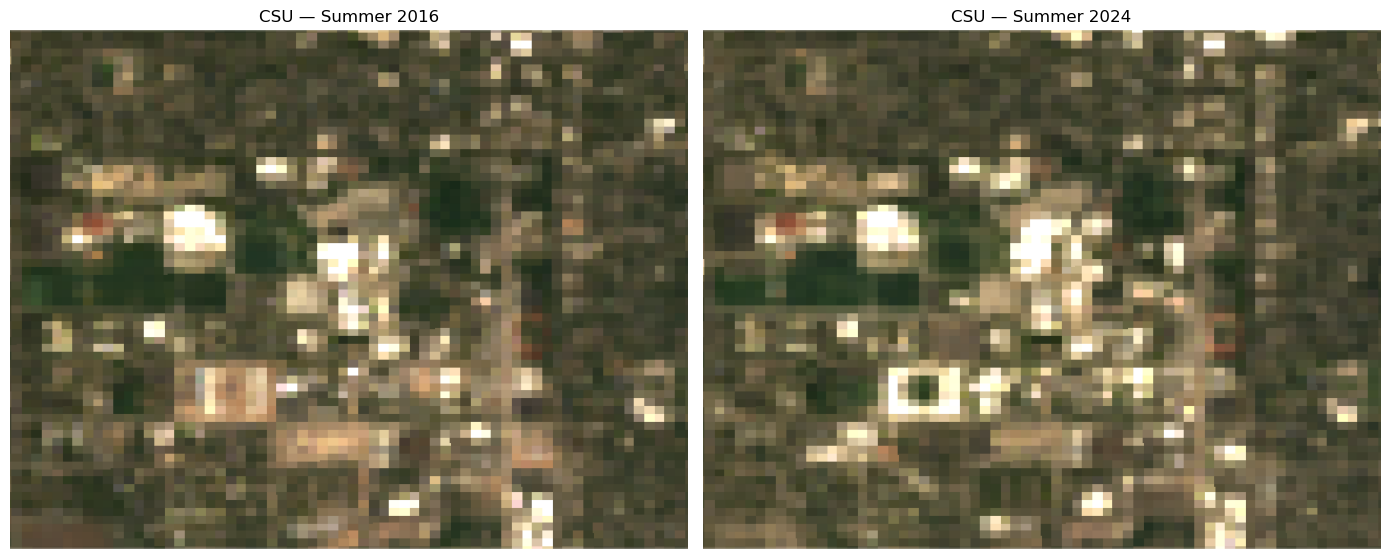

✅ Saved → figures/csu_landsat_comparison.png


In [9]:
def get_ee_thumbnail(image, vis_params, region, size=512):
    """Fetch a GEE image as a PIL Image for matplotlib/savefig."""
    params = {**vis_params, 'region': region.getInfo(),
              'dimensions': size, 'format': 'png'}
    url = image.getThumbURL(params)
    return Image.open(BytesIO(requests.get(url).content))

thumb_2016 = get_ee_thumbnail(landsat_2016, rgb_vis, csu_aoi)
thumb_2024 = get_ee_thumbnail(landsat_2024, rgb_vis, csu_aoi)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(thumb_2016); axes[0].set_title('CSU — Summer 2016'); axes[0].axis('off')
axes[1].imshow(thumb_2024); axes[1].set_title('CSU — Summer 2024'); axes[1].axis('off')
plt.tight_layout()
plt.savefig('figures/csu_landsat_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved → figures/csu_landsat_comparison.png")

### 🏋️ Exercise 1

**1a.** Load a **winter** Landsat composite for CSU (dates `'2024-01-01'` to `'2024-03-31'`).
How does it look different from the summer image?

**1b.** Display the winter image in **false color (NIR)**.
Can you still see vegetation? What does snow look like in false color?

*Hint: copy the summer composite cells above and change the dates and variable names.*

In [10]:
# ✏️ Exercise 1a — winter 2024 composite
# Your code here...
landsat_winter_2024 = (
ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
.merge(ee.ImageCollection('LANDSAT/LC09/C02/T1_L2'))
.filterBounds(csu_aoi)
.filterDate('2024-01-01', '2024-03-31')
.filter(ee.Filter.lt('CLOUD_COVER', 10))
.map(apply_scale_factors)
.median()
.clip(csu_aoi)
)

In [11]:
# ✏️ Exercise 1b — winter false color
# Your code here...
Map_winter_fc = geemap.Map(center=[csu_lat, csu_lon], zoom=14)
Map_winter_fc.addLayer(landsat_winter_2024, false_color_vis, 'Winter 2024 False Color (NIR)')
show_map(Map_winter_fc)

Map(center=[40.5734, -105.0844], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

---
## 💾 Save Your Work

1. Click the **Source Control** icon (left sidebar) — it looks like a branching tree.
2. Stage all changed files with **+**.
3. Write a commit message, e.g. `"Complete notebook 2 NDVI exercises"`.
4. Click **Commit & Push**.

⚠️ Push to **your branch only**, not `main`.

---
➡️ **Next:** Open **Notebook 2** to compute vegetation indices (NDVI).